<a href="https://colab.research.google.com/github/eshagupta1010/python-hw-/blob/main/Esha_Gupta_Assignment_3_International_Office_Part_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You are the Chief People Officer (CPO) for Global Analytics Solutions - for now. The board was not pleased with your original recommendations and came back with a series of seemingly unrelated queries regarding the dataset.

You and a data analyst worked together to translate these requests to Python workflows. Unfortunately the analyst then resigned, leaving you alone to complete the work.

The full dataset is the [same](https://raw.githubusercontent.com/ninilin2023/teaching/refs/heads/main/international_office.csv). Good luck.



## 1.Using method chaining, calculate the median gdp growth rate by income level for countries in Asia Pacific. Ensure that the categories are displayed in the output in their natural ordering (i.e., Low income, Lower middle income, etc..).  What do you notice about the results?

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
offices = pd.read_csv("https://raw.githubusercontent.com/ninilin2023/teaching/refs/heads/main/international_office.csv")

In [114]:
offices.columns

Index(['country', 'country_code', 'region', 'income_level', 'college_share',
       'inflation', 'gdp', 'gdp_capita', 'gdp_growth', 'life_expect',
       'population', 'unemployment', 'gini', 'temp_c'],
      dtype='object')

In [115]:
pd.Categorical(offices["income_level"], categories = ["Low Income", "Lower middle income", "Upper middle income", "High income"], ordered=True)
avg_gdp_growth_asia = offices[offices["region"] == "Asia Pacific"].groupby("income_level")["gdp_growth"].agg("median")
print(avg_gdp_growth_asia)

income_level
High income            2.1
Low income             7.0
Lower middle income    5.4
Upper middle income    4.4
Name: gdp_growth, dtype: float64


## 2.What is the correlation coeficient between inflation and unemployment? Would you consider this a strong correlation value?

In [116]:
print(f"The correlation coefficient between inflation and unemployment is: {round(float(offices["inflation"].corr(offices["unemployment"])),2)}. This is a fairly weak positive correlation.")

The correlation coefficient between inflation and unemployment is: 0.17. This is a fairly weak positive correlation.


## 3.Create a scatter plot for the two numeric variables that have the ***strongest*** correlation coefficient.

*Hint: You can use code automatically retrieve the two variables. Alternatively you can just compare the correlation outputs directly.*

The strongest correlation is between college_share and life_expect, and the value is 0.79


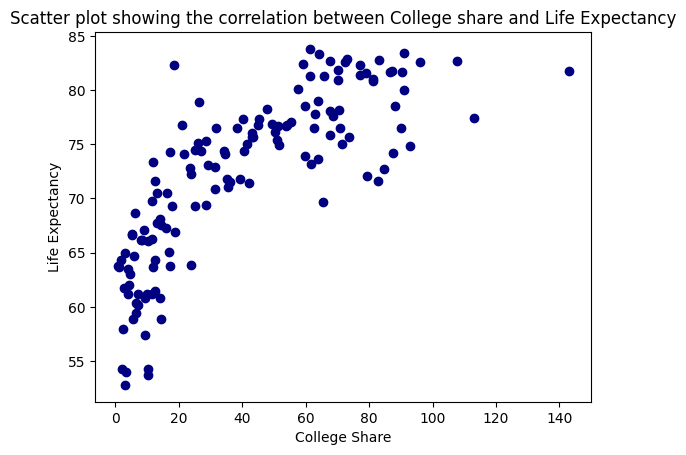

In [117]:
from numpy._core.defchararray import title
# DATA PREPARATION
# making correlation matrix to see all correlations
correlation_matrix = offices.corr(numeric_only=True)

# removing diagonal 1's to identify strongest correlation
abs_corr = correlation_matrix.abs()
np.fill_diagonal(abs_corr.values, np.nan)

# extracting the strongest correlation
strongest_pair = abs_corr.unstack().idxmax()
var1, var2 = strongest_pair
corr_coef = correlation_matrix.loc[var1, var2]

# printing column names and correlation
print(f"The strongest correlation is between {var1} and {var2}, and the value is {corr_coef:.2f}")

# VISUALIZATION
plt.scatter(offices["college_share"], offices["life_expect"], c="navy")
plt.title("Scatter plot showing the correlation between College share and Life Expectancy")
plt.xlabel("College Share")
plt.ylabel("Life Expectancy")
plt.show()


## 4.Apply .nlargest() and .nsmallest() to find the top 3 and bottom 3 countries globally by life expectancy. Create and print a combined DataFrame showing these 6 countries with all their metrics, sorted from shortest to longest life expectancy.

In [147]:
life_expect_largest = offices.nlargest(3, "life_expect", keep="all")
life_expect_smallest = offices.nsmallest(3, "life_expect", keep="all")
combined_expectency = pd.concat([life_expect_smallest, life_expect_largest]).sort_values(by="life_expect").reset_index(drop=True)
display(combined_expectency)

,country,country_code,region,income_level,college_share,inflation,gdp,gdp_capita,gdp_growth,life_expect,population,unemployment,gini,temp_c,temp_ranked
0,Central African Republic,CAF,Middle East & Africa,Low income,3.0,2.4,1822841757,384,3.0,52.8,4745185,3.7,56.2,24.9,32.0
1,Lesotho,LSO,Middle East & Africa,Lower middle income,10.2,1.6,2874585679,1353,-0.8,53.7,2125268,22.8,44.9,11.9,2.0
2,Chad,TCD,Middle East & Africa,Low income,3.3,2.9,12976290262,814,3.2,54.0,15946876,1.9,43.3,26.6,38.0
3,Italy,ITA,Europe,High income,64.3,0.7,2151420719257,35680,0.3,83.3,60297396,9.8,35.9,13.5,38.0
4,Spain,ESP,Europe,High income,91.1,1.4,1572012697558,33393,2.0,83.4,47076781,13.0,34.7,13.3,37.0
5,Switzerland,CHE,Europe,High income,61.4,0.4,680898749177,79407,0.9,83.8,8574832,4.8,32.7,5.5,8.0


## 5.Using .rank(), create a ranking for each country **within their region** for average temperature (e.g., temp_c) with warmer temperatures getting a higher rank. Return a new DataFrame that has countries that rank in the top 3, revealing the country name, region,  average temperature, and average temperature rank.

In [148]:
# grouping by region & temp_c and then ranking temperature by region
offices["temp_ranked"] = offices.groupby("region")["temp_c"].rank(method="min", ascending=False)

# keeping only the top 3 ranks
top_ranked = offices[offices["temp_ranked"] <= 3]

#printing top 3 ranks region
display(top_ranked.sort_values(["region", "temp_ranked"])[["country", "region", "temp_c", "temp_ranked"]])

,country,region,temp_c,temp_ranked
54,Guyana,Americas,26.0,1.0
127,Trinidad and Tobago,Americas,25.8,2.0
102,Panama,Americas,25.4,3.0
136,"Venezuela, RB",Americas,25.4,3.0
75,Sri Lanka,Asia Pacific,27.0,1.0
123,Thailand,Asia Pacific,26.3,2.0
59,Indonesia,Asia Pacific,25.9,3.0
104,Philippines,Asia Pacific,25.9,3.0
30,Cyprus,Europe,19.5,1.0
107,Portugal,Europe,15.2,2.0


## 6.Create a new column called `country_length` that shows the number of characters in each country name. Which region has countries with the longest average country name length?

*Hint: Use .apply(len) to count characters in each country name. We'll cover this in class on 9/15.*

In [119]:
offices["country_length"] = 0

## 7.Are there outlier countries in Europe for inflation? If so, which countries and which inflation values?

*Hint: Use the IQR approach (lower bound = Q1 - 1.5×IQR, upper bound = Q3 + 1.5×IQR). We'll cover this in class on 9/15.*

 ## 8.Create two crosstab tables showing regions as rows and income levels as columns. One showing total counts and one showing column percentages. Make sure the income levels are displayed in their natural ordering.

## 9.Using .agg() with multiple functions, create a summary table for each region showing: count of countries, and the mean, median, min, and max values for GDP per capita - all in one operation.

## 10.Classify each country's Inflation Risk and Unemployment Risk into Low/Medium/High categories, then create two tables.
* Inflation Risk: low <3%, medium 3-10%, high >10%
* Unemployment Risk: low <5%, medium 5-10%, high >10%
* First Table: counts for how many qualifying countries fall into each risk category combination - including row and column totals.
* Second Table: percentages for how big each group is relative to all countries.

# Reflection Questions

1. What are some challenges you encountered?
2. How effective are LLMs at explaining and diagnosing the coding errors?
3. If you are using an LLM for assistance, what is your impression of the code it generates? (3-5 sentences)